In [1]:
import numpy as np
import pandas as pd
import gzip
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv('training_25_features.csv')

# print df
print(df.shape)
df.head()

(4319176, 26)


,I,II,III,aVF,aVR,aVL,V1,V2,V3,V4,...,weight,nurse,site,device,heart_axis,validated_by,second_opinion,validated_by_human,pacemaker,strat_fold
0,-0.005,0.135,0.140,-0.065,-0.073,0.137,-0.125,-0.090,-0.110,-0.210,...,69.841845,0.0,0.0,0,3.0,0.0,0,0,0.0,6
1,-0.005,0.135,0.140,-0.065,-0.073,0.137,-0.125,-0.090,-0.110,-0.211,...,69.841845,0.0,0.0,0,3.0,0.0,0,0,0.0,6
2,-0.005,0.131,0.136,-0.063,-0.070,0.133,-0.125,-0.082,-0.102,-0.190,...,69.841845,0.0,0.0,0,3.0,0.0,0,0,0.0,6
3,-0.005,0.130,0.135,-0.063,-0.070,0.132,-0.122,-0.077,-0.094,-0.172,...,69.841845,0.0,0.0,0,3.0,0.0,0,0,0.0,6
4,-0.005,0.128,0.133,-0.062,-0.069,0.130,-0.119,-0.071,-0.084,-0.157,...,69.841845,0.0,0.0,0,3.0,0.0,0,0,0.0,6


In [3]:
# convert all the columns to float64
for i in range(26):
    df[df.columns[i]] = df[df.columns[i]].astype('float64')

# get info for columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4319176 entries, 0 to 4319175
Data columns (total 26 columns):
 #   Column              Dtype  
---  ------              -----  
 0   I                   float64
 1   II                  float64
 2   III                 float64
 3   aVF                 float64
 4   aVR                 float64
 5   aVL                 float64
 6   V1                  float64
 7   V2                  float64
 8   V3                  float64
 9   V4                  float64
 10  V5                  float64
 11  V6                  float64
 12  ritmi               float64
 13  age                 float64
 14  sex                 float64
 15  height              float64
 16  weight              float64
 17  nurse               float64
 18  site                float64
 19  device              float64
 20  heart_axis          float64
 21  validated_by        float64
 22  second_opinion      float64
 23  validated_by_human  float64
 24  pacemaker           float64
 25  st

In [4]:
columns_to_drop = [
    "nurse",
    "site",
    "device",
    "heart_axis",
    "validated_by",
    "second_opinion",
    "validated_by_human",
    "pacemaker",
    "strat_fold"
]

df = df.drop(columns=columns_to_drop)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4319176 entries, 0 to 4319175
Data columns (total 17 columns):
 #   Column  Dtype  
---  ------  -----  
 0   I       float64
 1   II      float64
 2   III     float64
 3   aVF     float64
 4   aVR     float64
 5   aVL     float64
 6   V1      float64
 7   V2      float64
 8   V3      float64
 9   V4      float64
 10  V5      float64
 11  V6      float64
 12  ritmi   float64
 13  age     float64
 14  sex     float64
 15  height  float64
 16  weight  float64
dtypes: float64(17)
memory usage: 560.2 MB


In [6]:
# Reduce to 500k rows
df_sample = df.sample(500000, random_state=42)

# Convert to efficient types
df_sample = df_sample.astype("float32")
df_sample["ritmi"] = df_sample["ritmi"].astype("int32")

In [7]:
X = df_sample.drop(columns=["ritmi"])
y = df_sample["ritmi"]

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

KNN MODEL IMPLEMENTATION

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_model = KNeighborsClassifier(
    n_neighbors=5,
    n_jobs=4
)

knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_jobs=4)

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# KNN predictions
y_pred_knn = knn_model.predict(X_test_scaled)

print("\n===== KNN RESULTS =====")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))


===== KNN RESULTS =====
Accuracy: 0.82051
              precision    recall  f1-score   support

           0       0.80      0.83      0.81     31140
           1       0.80      0.79      0.79     24803
           2       0.85      0.83      0.84     44057

    accuracy                           0.82    100000
   macro avg       0.82      0.82      0.82    100000
weighted avg       0.82      0.82      0.82    100000

Confusion Matrix:
 [[25880  1727  3533]
 [ 2322 19659  2822]
 [ 4273  3272 36512]]


RANDOM FOREST MODEL IMPLEMENTATION

In [12]:
# random forest classification algorithm by haneek
rf = RandomForestClassifier()
rf_param_grid = {'n_estimators': [45], 'criterion': ['entropy'], 'max_depth': [45]}
rf_cv= GridSearchCV(rf,rf_param_grid,cv=7)
rf_cv.fit(X_train,y_train)

print("Best Score:" + str(rf_cv.best_score_))
print("Best Parameters: " + str(rf_cv.best_params_))

Best Score:0.87476500210783
Best Parameters: {'criterion': 'entropy', 'max_depth': 45, 'n_estimators': 45}


BEST RANDOM FOREST MODEL

In [15]:
best_rf = rf_cv.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print("===== RANDOM FOREST RESULTS =====")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

===== RANDOM FOREST RESULTS =====
Accuracy: 0.88638
              precision    recall  f1-score   support

           0       0.92      0.85      0.89     31140
           1       0.87      0.86      0.87     24803
           2       0.87      0.92      0.90     44057

    accuracy                           0.89    100000
   macro avg       0.89      0.88      0.88    100000
weighted avg       0.89      0.89      0.89    100000



Build a KNN pipeline (scaling inside)

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5, n_jobs=4))
])

In [22]:
from sklearn.pipeline import Pipeline

rf_pipe = Pipeline([
    ("rf", best_rf)   # best_rf from your GridSearchCV
])

HARD VOTING Ensemble Model Implementation

In [30]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

hard_ensemble_model = VotingClassifier(
    estimators=[
        ("rf", rf_pipe),
        ("knn", knn_pipe),
    ],
    voting="hard"
)

hard_ensemble_model.fit(X_train, y_train)
y_pred_ensemble = hard_ensemble_model.predict(X_test)

print("===== ENSEMBLE (HARD VOTING) =====")
print("Accuracy:", accuracy_score(y_test, y_pred_ensemble))
print(classification_report(y_test, y_pred_ensemble))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ensemble))

===== ENSEMBLE (HARD VOTING) =====
Accuracy: 0.84683
              precision    recall  f1-score   support

           0       0.79      0.91      0.85     31140
           1       0.81      0.84      0.83     24803
           2       0.92      0.81      0.86     44057

    accuracy                           0.85    100000
   macro avg       0.84      0.85      0.84    100000
weighted avg       0.85      0.85      0.85    100000

Confusion Matrix:
 [[28295  1201  1644]
 [ 2647 20896  1260]
 [ 4829  3736 35492]]


SOFT VOTING ENSEMBLE MODEL

In [31]:
soft_ensemble_model = VotingClassifier(
    estimators=[
        ("rf", rf_pipe),
        ("knn", knn_pipe),
    ],
    voting="soft",
    weights=[2, 1]   # RF stronger than KNN
)

soft_ensemble_model.fit(X_train, y_train)
y_pred_ensemble = soft_ensemble_model.predict(X_test)
print("===== ENSEMBLE (SOFT VOTING) =====")
print("Accuracy:", accuracy_score(y_test, y_pred_ensemble))
print(classification_report(y_test, y_pred_ensemble))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ensemble))

===== ENSEMBLE (SOFT VOTING) =====
Accuracy: 0.87755
              precision    recall  f1-score   support

           0       0.91      0.85      0.88     31140
           1       0.86      0.85      0.86     24803
           2       0.87      0.91      0.89     44057

    accuracy                           0.88    100000
   macro avg       0.88      0.87      0.87    100000
weighted avg       0.88      0.88      0.88    100000

Confusion Matrix:
 [[26475  1241  3424]
 [  947 21107  2749]
 [ 1823  2061 40173]]


WEIGHTED ENSEMBLE MODEL

In [26]:
# --- Weighted soft voting (RF weighted higher than KNN) ---
weighted_voting = VotingClassifier(
    estimators=[
        ("rf", rf_pipe),
        ("knn", knn_pipe),
    ],
    voting="soft",
    weights=[3, 1]   # try [2,1] or [4,1] too
)

weighted_voting.fit(X_train, y_train)
y_pred_wv = weighted_voting.predict(X_test)

print("===== WEIGHTED SOFT VOTING RESULTS =====")
print("Accuracy:", accuracy_score(y_test, y_pred_wv))
print(classification_report(y_test, y_pred_wv))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_wv))

===== WEIGHTED SOFT VOTING RESULTS =====
Accuracy: 0.88274
              precision    recall  f1-score   support

           0       0.91      0.86      0.88     31140
           1       0.87      0.86      0.86     24803
           2       0.87      0.92      0.89     44057

    accuracy                           0.88    100000
   macro avg       0.88      0.88      0.88    100000
weighted avg       0.88      0.88      0.88    100000

Confusion Matrix:
 [[26628  1197  3315]
 [  878 21253  2672]
 [ 1652  2012 40393]]


STACKING ENSEMBLE MODEL

In [29]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# --- Meta-model (final estimator) ---
meta_model = LogisticRegression(max_iter=2000, n_jobs=4)

stacking_model = StackingClassifier(
    estimators=[
        ("rf", rf_pipe),
        ("knn", knn_pipe),
    ],
    final_estimator=meta_model,
    stack_method="predict_proba",  # important for multiclass
    cv=5,
    n_jobs=4,
    passthrough=True  # set True if you want meta-model to also see original features
)

stacking_model.fit(X_train, y_train)
y_pred_stack = stacking_model.predict(X_test)

print("===== STACKING RESULTS =====")
print("Accuracy:", accuracy_score(y_test, y_pred_stack))
print(classification_report(y_test, y_pred_stack))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_stack))

Exception ignored in: <function ResourceTracker.__del__ at 0x1047c6f20>
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.12/3.12.12_2/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/homebrew/Cellar/python@3.12/3.12.12_2/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/homebrew/Cellar/python@3.12/3.12.12_2/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes


===== STACKING RESULTS =====
Accuracy: 0.88843
              precision    recall  f1-score   support

           0       0.90      0.88      0.89     31140
           1       0.87      0.86      0.87     24803
           2       0.89      0.91      0.90     44057

    accuracy                           0.89    100000
   macro avg       0.89      0.88      0.89    100000
weighted avg       0.89      0.89      0.89    100000

Confusion Matrix:
 [[27337  1143  2660]
 [  970 21442  2391]
 [ 1933  2060 40064]]


In [33]:
# 1) Fit KNN pipeline (scaler + knn)
knn_pipe.fit(X_train, y_train)

# 3) Fit ensembles
hard_ensemble_model.fit(X_train, y_train)
soft_ensemble_model.fit(X_train, y_train)
weighted_voting.fit(X_train, y_train)
stacking_model.fit(X_train, y_train)

StackingClassifier(cv=5,
                   estimators=[('rf',
                                Pipeline(steps=[('rf',
                                                 RandomForestClassifier(criterion='entropy',
                                                                        max_depth=45,
                                                                        n_estimators=45))])),
                               ('knn',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('knn',
                                                 KNeighborsClassifier(n_jobs=4))]))],
                   final_estimator=LogisticRegression(max_iter=2000, n_jobs=4),
                   n_jobs=4, passthrough=True, stack_method='predict_proba')

Model Comparison table

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.exceptions import NotFittedError
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix
)

def eval_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro", zero_division=0
    )
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(
        y_test, y_pred, average="weighted", zero_division=0
    )

    return {
        "accuracy": acc,
        "precision_macro": p_macro,
        "recall_macro": r_macro,
        "f1_macro": f1_macro,
        "precision_weighted": p_w,
        "recall_weighted": r_w,
        "f1_weighted": f1_w,
        "confusion_matrix": confusion_matrix(y_test, y_pred),
    }

models = {
    "KNN": knn_pipe,
    "RandomForest": best_rf,
    "Hard Voting": hard_ensemble_model,
    "Soft Voting": soft_ensemble_model,
    "Weighted Soft Voting": weighted_voting,
    "Stacking": stacking_model,
}

rows = []
cms = {}

for name, model in models.items():
    try:
        m = eval_model(model, X_test, y_test)
        cms[name] = m.pop("confusion_matrix")
        m["model"] = name
        rows.append(m)
    except NotFittedError:
        print(f"Skipping {name}: model not fitted")

metrics_df = pd.DataFrame(rows).set_index("model").sort_values("accuracy", ascending=False)

display(metrics_df.round(4))

Exception ignored in: <function ResourceTracker.__del__ at 0x104ea2f20>
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.12/3.12.12_2/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/homebrew/Cellar/python@3.12/3.12.12_2/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/homebrew/Cellar/python@3.12/3.12.12_2/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x11902af20>
Traceback (most recent call last):
  File "/opt/homebrew/Cellar/python@3.12/3.12.12_2/Frameworks/Python.framework/Versions/3.12/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/homebrew/Cellar/python@3.12/3.12.12_2/Frameworks/Python.

,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
model,,,,,,,
Stacking,0.8887,0.8879,0.8843,0.8860,0.8888,0.8887,0.8887
RandomForest,0.8864,0.8883,0.8799,0.8834,0.8876,0.8864,0.8863
Weighted Soft Voting,0.8847,0.8866,0.8783,0.8819,0.8855,0.8847,0.8845
Soft Voting,0.8787,0.8800,0.8722,0.8756,0.8794,0.8787,0.8786
Hard Voting,0.8468,0.8415,0.8521,0.8440,0.8542,0.8468,0.8474
KNN,0.8205,0.8153,0.8175,0.8162,0.8212,0.8205,0.8207


Model Comparison plots

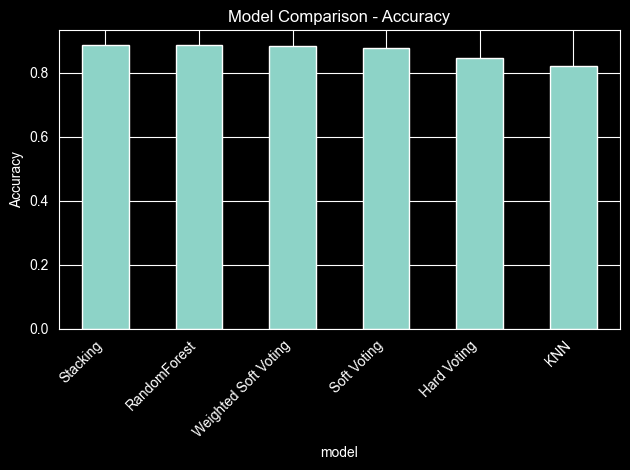

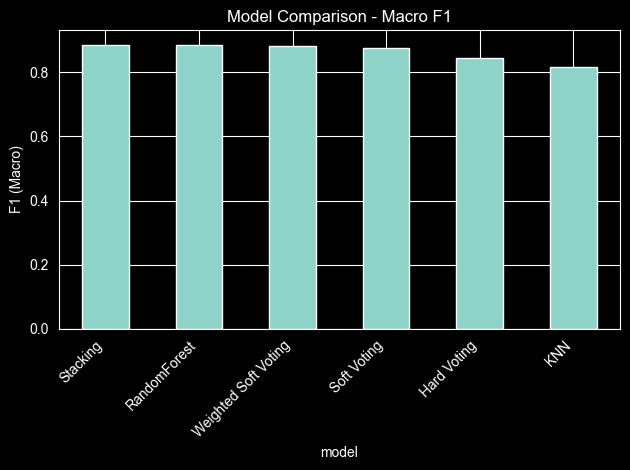

<Figure size 640x480 with 0 Axes>

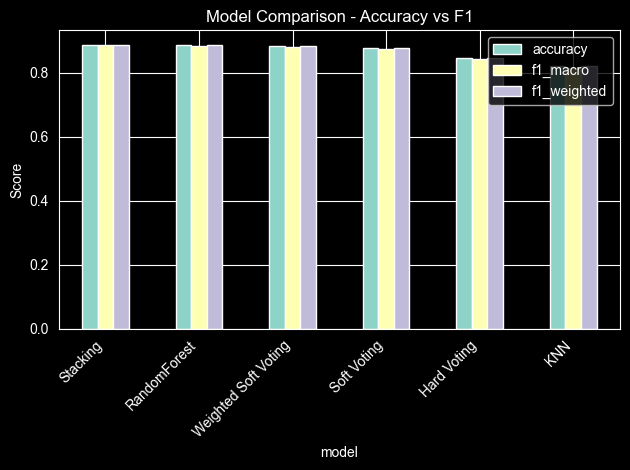

In [35]:
# Accuracy plot
plt.figure()
metrics_df["accuracy"].plot(kind="bar")
plt.title("Model Comparison - Accuracy")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Macro F1 plot (best for multiclass fairness)
plt.figure()
metrics_df["f1_macro"].plot(kind="bar")
plt.title("Model Comparison - Macro F1")
plt.ylabel("F1 (Macro)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Combined plot: accuracy + F1s
plt.figure()
metrics_df[["accuracy", "f1_macro", "f1_weighted"]].plot(kind="bar")
plt.title("Model Comparison - Accuracy vs F1")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Testing Prediction using Dummy Data

In [38]:
import pandas as pd

# ✅ Column names (features used in training — EXCLUDE 'ritmi')
feature_cols = [
    "I","II","III","aVF","aVR","aVL",
    "V1","V2","V3","V4","V5","V6",
    "age","sex","height","weight"
]

# ✅ Dummy row (same order as feature_cols)
dummy_row = [[
    1,      # I
    -0.005, # II
    0.135,  # III
    0.140,  # aVF
    -0.065, # aVR
    -0.073, # aVL
    0.137,  # V1
    -0.125, # V2
    -0.090, # V3
    -0.110, # V4
    -0.211, # V5
    -0.146, # V6
    54.0,   # age
    0,      # sex
    166.796356, # height
    69.841845   # weight
]]

# Create DataFrame
X_dummy = pd.DataFrame(dummy_row, columns=feature_cols)

# ✅ Predict class (0/1/2)
pred_class = stacking_model.predict(X_dummy)[0]
print("Predicted class:", pred_class)

# ✅ Predict probabilities (recommended for confidence)
proba = stacking_model.predict_proba(X_dummy)[0]
print("Class probabilities:", proba)
print("Predicted probability:", proba[pred_class])

label_map = {0: "Normal", 1: "Law Risk", 2: "High Risk"}  # rename as your real labels
print("Predicted label:", label_map[int(pred_class)])

Predicted class: 2
Class probabilities: [0.25189873 0.25781788 0.49028339]
Predicted probability: 0.49028338622316586
Predicted label: High Risk


Model Save for Production

In [ ]:
import joblib

joblib.dump(stacking_model, "model_pickle.pkl")

print("Model saved successfully ✅")

Model saved successfully ✅
